In [1]:
#mounting Drive for reading the scraped file
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

%cd drive/MyDrive/system_security

Mounted at /content/drive
/content/drive/MyDrive/system_security


In [3]:
#Importing Libraries
import pandas as pd
import re
import nltk
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
#Setting up the DataFrame Structre to read the code lines
df_nosec=pd.DataFrame()
df_nosec['path']=''
df_nosec['code']=''
df_nosec['nosec_categories']=''
df_nosec['bandit_codes']=''
df_nosec['repo_name']=''

In [5]:
#function to extract comments which has "nosec"
def extract_categories_nosec(code):
  regex_pattern = r'#\s*nosec(.*)'
  code_match=re.search(regex_pattern, code)
  if(code_match):
    code=code_match.group(1)
    code_token=code.split('#')

    result=[]
    exceptions=['nosec','#','noqa:',""," ", "noqa", "nosec:",":"]
    for token in code_token:
      sub_tokens=token.split(" ")
      for sub_token in sub_tokens:

        if(sub_token not in exceptions):
          result.append(sub_token)
    return ",".join(result)
  else:
    return ""



#Parsing the nosec logs and extracting the code, comments, Bandit codes and the file paths

with open('nosec_logs_more_filtered.txt', 'r') as file:

    for line in file:

        regex_pattern_code = r'[^:]*:[^:]*:(.*)' # Regex for extracting code part
        regex_pattern_path = r'^[^:]*:[^:]*'  # Regex for matching the path
        regex_pattern_bandit_category = r'\b[A-Z]\d{3}\b' # Regex for matching bandit code


        match_code = re.search(regex_pattern_code, line)
        match_path = re.search(regex_pattern_path, line)
        repo_name= line.split('/')[2]
        code=""
        path=""
        if(match_code):
          code=match_code.group(1).strip()
        if(match_path):
          path=match_path.group(0).strip()
        if(match_code and match_path):
            match_category = re.findall(regex_pattern_bandit_category,code)
            new_df = pd.DataFrame({'path':[path.lstrip().rstrip()],
                                   'code':[code.lstrip().rstrip().split('#')[0]],
                                   'nosec_categories':[extract_categories_nosec(code)],
                                   'bandit_codes':[ ",".join(match_category) if match_category else " " ],
                                   'repo_name':[repo_name]})
            df_nosec = pd.concat([df_nosec, new_df], axis=0, ignore_index=True)



In [6]:
#adding additional features column to the dataframe for further Analysis
df_nosec['functions']='' # This column Holds the function Name
df_nosec['import']='' # This column Holds the Import Library Name
df_nosec['variables']='' # This column Holds the Variables Name used in the line of the code
df_nosec['others']=''
df_nosec['except_flag']='' # Flag if the code has "Exception"
df_nosec['assert_flag']='' # Flag if Assert is used

In [7]:
#In the below code we are identifying the function calls, Import Libraries and marking the presence of Exception and Import Libraries from the Nosec Logs.

for i in range(df_nosec.shape[0]):
  code_line=df_nosec.iloc[i]['code']

  function_calls = ','.join(re.findall(r'(\w+)\s*\(', code_line))  # Regex for matching function calls


  variables = ','.join(re.findall(r'\b(\w+)\b', code_line)) # Regex for matching Variables


  other_features = ','.join([token for token in re.split(r'[\s\(\)]+', code_line) if token]) # Matching remaing tokens

  import_state = re.findall(r'import\s+(\w+)(?:\s+as\s+\w+)?|(?:from\s+(\w+)\s+import\s+(\w+))|(?:import\s+(\w+)(?:,\s+\w+)*)', code_line) # Regex for matching Import  Libraries


  df_nosec.loc[i,'functions']=function_calls

  if(import_state!=[]):
    df_nosec.loc[i,'import']=','.join(import_state[0])
  else:
    df_nosec.loc[i,'import']=''

  df_nosec.loc[i,'variables']=variables
  df_nosec.loc[i,'others']=other_features

  #Setting Assert Flag
  if('assert' in code_line.lower()):
    df_nosec.loc[i,'assert_flag']= True
  #setting Exception Flag
  if(('except' in code_line.lower()) or ('exception' in code_line.lower())):
    df_nosec.loc[i,'except_flag']= True



In [8]:
##Bandit Code explode and Grouping
df_nosec['bandit_codes']=df_nosec['bandit_codes'].str.split(',')
df_nosec_exploded=df_nosec.explode('bandit_codes')

In [9]:
#Data Preparation for identifying Frequncy of Function calls and Import Libraries  which have "nosec" and
function_text=''
variable_text=''
import_text=''
for i in range(df_nosec.shape[0]):
  function_text= function_text+" "+" ".join(df_nosec.iloc[i]['functions'].lower().split(','))
  variable_text= variable_text+" "+" ".join(df_nosec.iloc[i]['variables'].lower().split(','))
  import_text= import_text+" "+" ".join(df_nosec.iloc[i]['import'].lower().split(','))




tokens_function_text = nltk.tokenize.word_tokenize(function_text)
tokens_variable_text = nltk.tokenize.word_tokenize(variable_text)
tokens_import_text = nltk.tokenize.word_tokenize(import_text)


fdist_function_text=FreqDist(tokens_function_text)
fdist_variable_text=FreqDist(tokens_variable_text)
fdist_import_text=FreqDist(tokens_import_text)

data_function_text = {'Term': list(fdist_function_text.keys()), 'Frequency': list(fdist_function_text.values())}
df_function_frequency=pd.DataFrame(data_function_text)

data_variable_text = {'Term': list(fdist_variable_text.keys()), 'Frequency': list(fdist_variable_text.values())}
df_variable_text=pd.DataFrame(data_variable_text)

data_import_text = {'Term': list(fdist_import_text.keys()), 'Frequency': list(fdist_import_text.values())}
df_import_text=pd.DataFrame(data_import_text)

In [10]:
# identifying frequency of Variables except for those cases where function calls and import library is not there

df_nosec_func_negate  = df_nosec[(df_nosec['functions']=='') & (df_nosec['import']== '')]
df_nosec_func_negate_variable_text=''
for i in range(df_nosec_func_negate.shape[0]):
  df_nosec_func_negate_variable_text= df_nosec_func_negate_variable_text+" "+" ".join(df_nosec_func_negate.iloc[i]['variables'].lower().split(','))
tokens_df_nosec_func_negate_variable_text = nltk.tokenize.word_tokenize(df_nosec_func_negate_variable_text)
fdist_tokens_df_nosec_func_negate_variable_text=FreqDist(tokens_df_nosec_func_negate_variable_text)
data_variables_negate = {'Term': list(fdist_tokens_df_nosec_func_negate_variable_text.keys()), 'Frequency': list(fdist_tokens_df_nosec_func_negate_variable_text.values())}
df_variables_negate=pd.DataFrame(data_variables_negate)

##Plotting Frequency of Variables in Nosec cases ( Excluding the lines of code which has function calls and import calls)

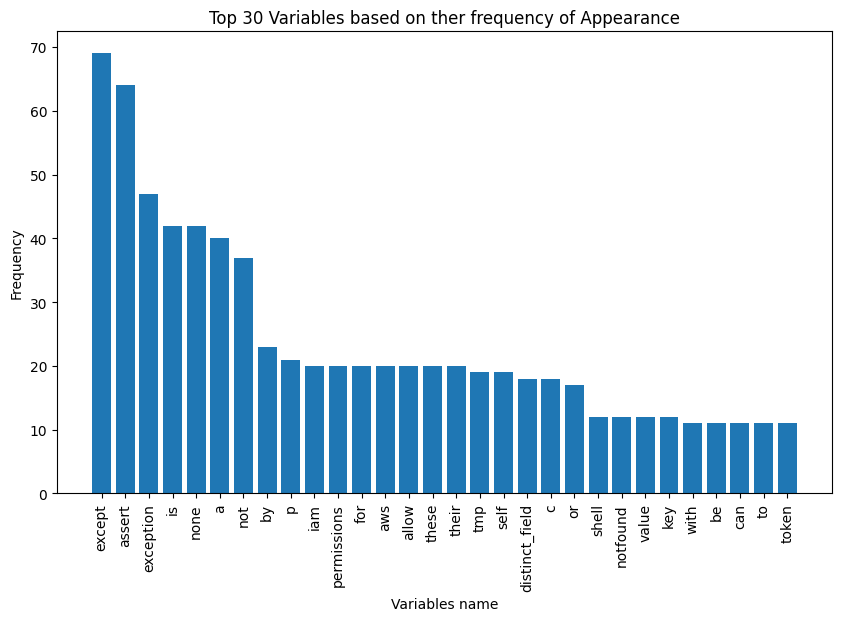

In [13]:


df_variables_negate_sorted = df_variables_negate[df_variables_negate['Term']!='0'].sort_values(by='Frequency', ascending=False)

# Select the top 20 rows
top_30 = df_variables_negate_sorted.head(30)

# Create a bar chart for the top 20 values
plt.figure(figsize=(10, 6))
plt.bar(top_30['Term'], top_30['Frequency'])
plt.xlabel('Variables name')
plt.ylabel('Frequency')
plt.title('Top 30 Variables based on ther frequency of Appearance')
plt.xticks(rotation=90)
plt.show()

##Plotting the function calls and their frequency of appearance in the lines of codes which is marked for nosec

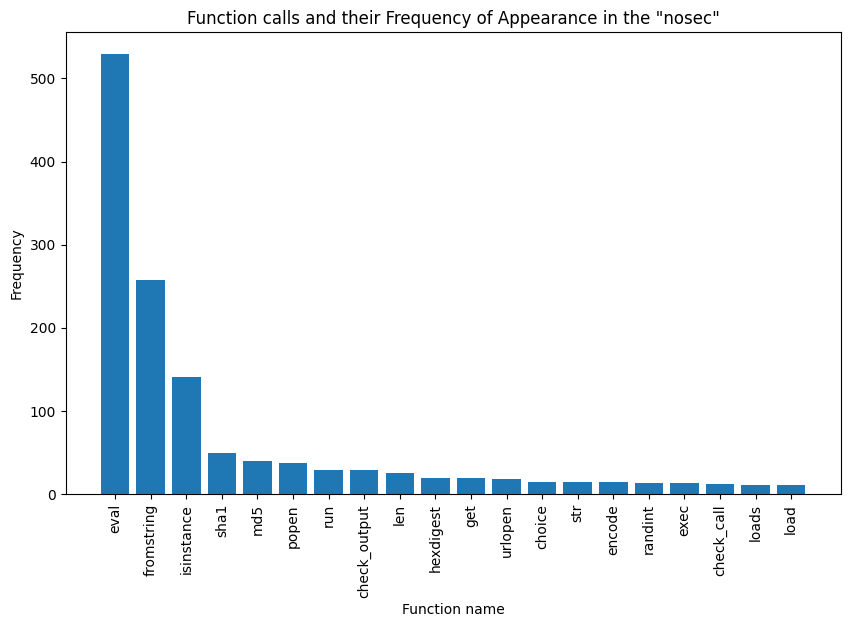

In [14]:

df_function_frequency_sorted = df_function_frequency.sort_values(by='Frequency', ascending=False)

# Select the top 20 rows
top_20 = df_function_frequency_sorted.head(20)

# Create a bar chart for the top 20 values
plt.figure(figsize=(10, 6))
plt.bar(top_20['Term'], top_20['Frequency'])
plt.xlabel('Function name')
plt.ylabel('Frequency')
plt.title('Function calls and their Frequency of Appearance in the "nosec"')
plt.xticks(rotation=90)
plt.show()

##Plotting the Import Libraries  and their frequency of appearance in the lines of codes which is marked for nosec

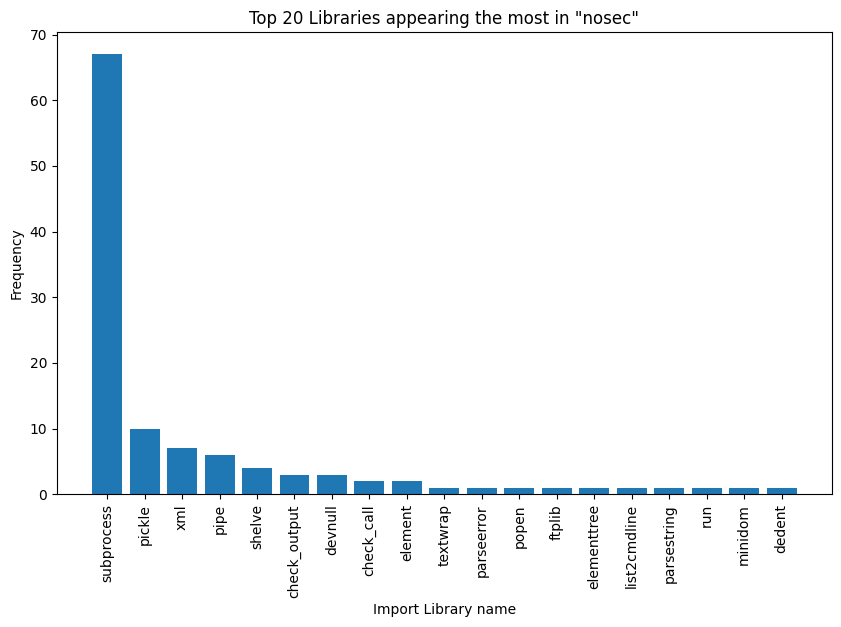

In [15]:
import matplotlib.pyplot as plt

df_import_text_sorted = df_import_text.sort_values(by='Frequency', ascending=False)

# Select the top 20 rows
top_20 = df_import_text_sorted.head(20)

# Create a bar chart for the top 20 values
plt.figure(figsize=(10, 6))
plt.bar(top_20['Term'], top_20['Frequency'])
plt.xlabel('Import Library name')
plt.ylabel('Frequency')
plt.title('Top 20 Libraries appearing the most in "nosec"')
plt.xticks(rotation=90)
plt.show()

##Plotting the frequency Bandit code usage for nosec comments

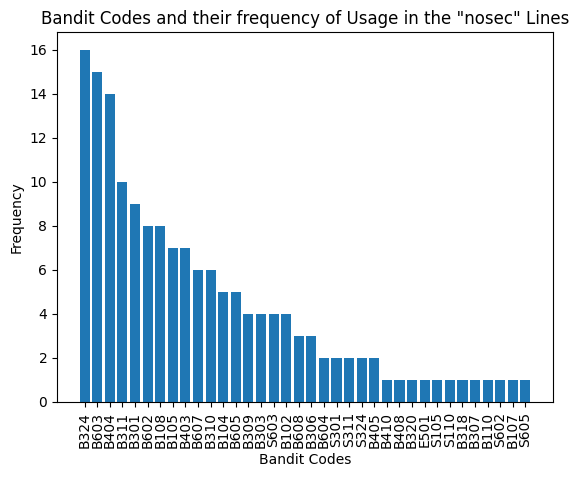

In [16]:

frequency_of_bandit_codes = df_nosec_exploded[df_nosec_exploded['bandit_codes']!=' '][['bandit_codes']].value_counts()
frequency_of_bandit_codes=pd.DataFrame(frequency_of_bandit_codes).reset_index().rename(columns={'bandit_codes':'bandit_codes','0':'Frequency'})

plt.bar(frequency_of_bandit_codes['bandit_codes'].values, frequency_of_bandit_codes[0])
plt.xlabel('Bandit Codes')
plt.ylabel('Frequency')
plt.title('Bandit Codes and their frequency of Usage in the "nosec" Lines')
plt.xticks(rotation=90)
plt.show()

# Distribution of Repositories in our sample and the number of "nosec" occurance in each of the repository. Plotting the top 20 Repository

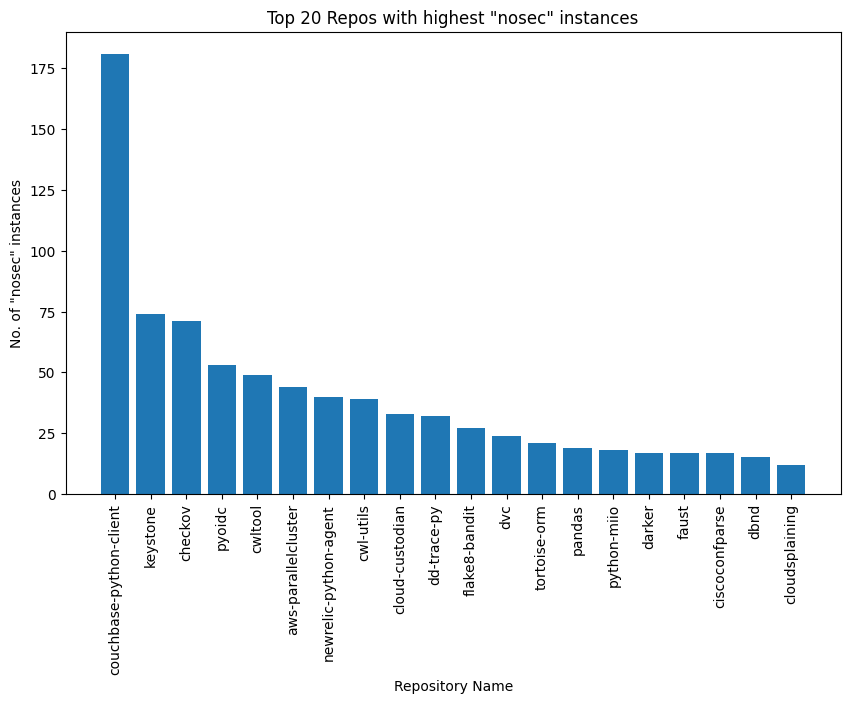

In [17]:
df_nosec_repo_distribution = df_nosec.groupby(['repo_name']).size().reset_index(name='Frequency')

df_nosec_repo_distribution_sorted = df_nosec_repo_distribution[df_nosec_repo_distribution['repo_name']!='azure-sdk-for-python'].sort_values(by='Frequency', ascending=False)

# Select the top 20 rows
top_20 = df_nosec_repo_distribution_sorted.head(20)

# Create a bar chart for the top 20 values
plt.figure(figsize=(10, 6))
plt.bar(top_20['repo_name'], top_20['Frequency'])
plt.xlabel('Repository Name')
plt.ylabel('No. of "nosec" instances')
plt.title('Top 20 Repos with highest "nosec" instances')
plt.xticks(rotation=90)
plt.show()


# Function calls which has been marked with "nosec" and their appearance across different repositories

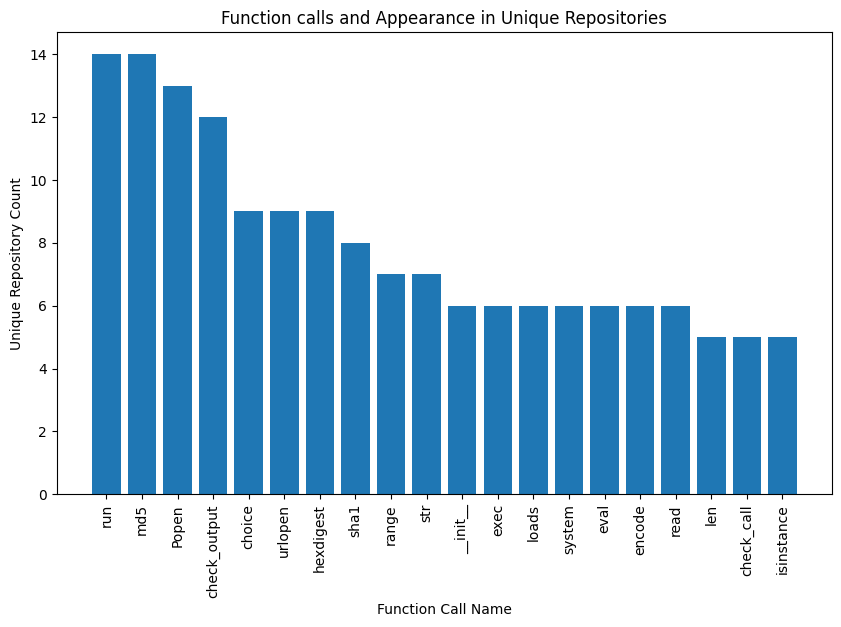

In [18]:
##Bandit Code explode and Grouping

df_nosec['functions']=df_nosec['functions'].str.split(',')
df_nosec_functions_exploded=df_nosec.explode('functions')

df_func_repo_count = df_nosec_functions_exploded[df_nosec_functions_exploded['functions']!=''].groupby(['functions']).repo_name.nunique().reset_index(name= 'No_Unique_Repo')

df_func_repo_count_sorted = df_func_repo_count.sort_values(by='No_Unique_Repo', ascending=False)

top_20 = df_func_repo_count_sorted.head(20)

# Create a bar chart for the top 20 values
plt.figure(figsize=(10, 6))
plt.bar(top_20['functions'], top_20['No_Unique_Repo'])
plt.xlabel('Function Call Name')
plt.ylabel('Unique Repository Count')
plt.title('Function calls and Appearance in Unique Repositories')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Percentage of nosec lines of code having Categories mentioned
df_nosec[df_nosec['bandit_codes']!=' '].shape[0]/df_nosec.shape[0]*100

7.340425531914893

# top 8000 PyPi  Repos Analyzed
## Found 282 Repos using Bandit
## Found 162 atleast have one nosec


## Key Observations
### 3.5 % of top 8000 pypi repos use bandit
### 57.4% of the repos that used bandit contained atleast one `nosec` usage
### Distribution of functions which to which exceptions were added (`nosec`) frequently across repositories

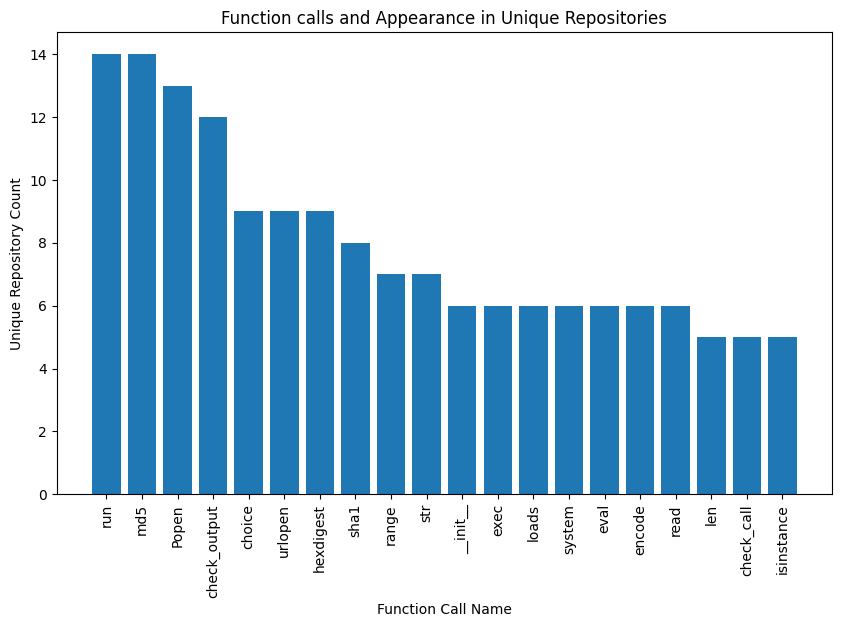

Here we see a list of unsafe (unless used with caution) functions. This suggests existence of vulnerabilities.



### Distribution of number of exceptions per repository

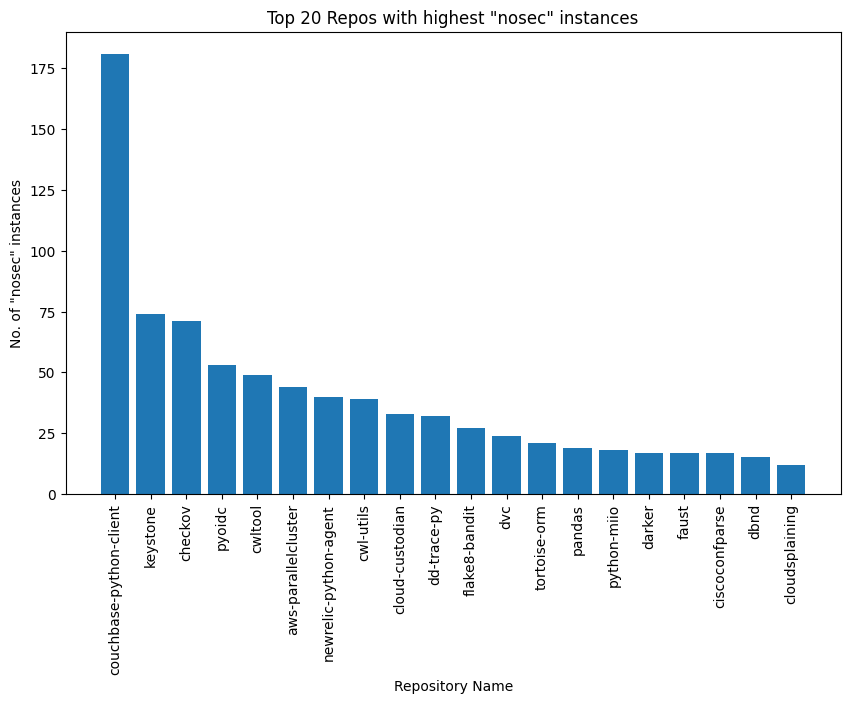

Here we see, the nosec is not used cautiously which suggests developer ignorance, and opens up possibility of bugs.

### 7.34% of the `nosec` exception has the category mentioned in it
This also suggests usage of exceptions is not carefully added